uni_section_v13: command_v13.md 반영 — Augmented Lagrangian Dual-Ascent + EWMA/히스테리시스 프루닝
  [§1] area를 목적함수로, Mp/collision을 AL 제약으로 분리(적응형 rho, mu<=1e5, grad_clip=10)
  [§2] Stage1(0-30)/Stage2(31-100)/Stage3(100-300), S_protect={0,1}, Inner Hat 40ep 유예
  [§3~4] entropy 정규화(Mp err 결합) + softplus collision(beta<=60, detach thickness)
  [§5~7] Cascade 옵티마이저 전체 재구성 + 항시-저가중 매끄러움 + t_clamp/Y-Snap jitter
[gradcheck] dMp/dt OK -- autograd=1.3173e+07, FD=1.3160e+07, rel_err=9.88e-04

[Cycle 0] Training | n_parts=5 | protect=(0, 1) | prunable=[2, 3, 4]
  target_area=1157.3 | Stage1<30 Stage2<100 Stage3>=100
  EWMA alpha=0.15 delete<0.08 restore>0.15 confirm=20ep
Ep || Loss | MpErr% | Area | Coll || St|tG|beta|betaCol || muMp|muCol|rhoMp || z_cont
0000 || 1196.254 | 47.17% |   1163 | 0.1474 || 1|0.00|0.70|1.0 || 1.0|1.0|200 || [1.00 1.00 0.96 0.96 0.96]
0019 || 1389099.375 | 69.97% |   1050 | 117.8078 || 1|0.00|0.70|1.0 || 1.0|1.0|200 || [1.00 1.00 0.96 0.96 0.96]
0030 || 2197.522 | 81.93% |    8

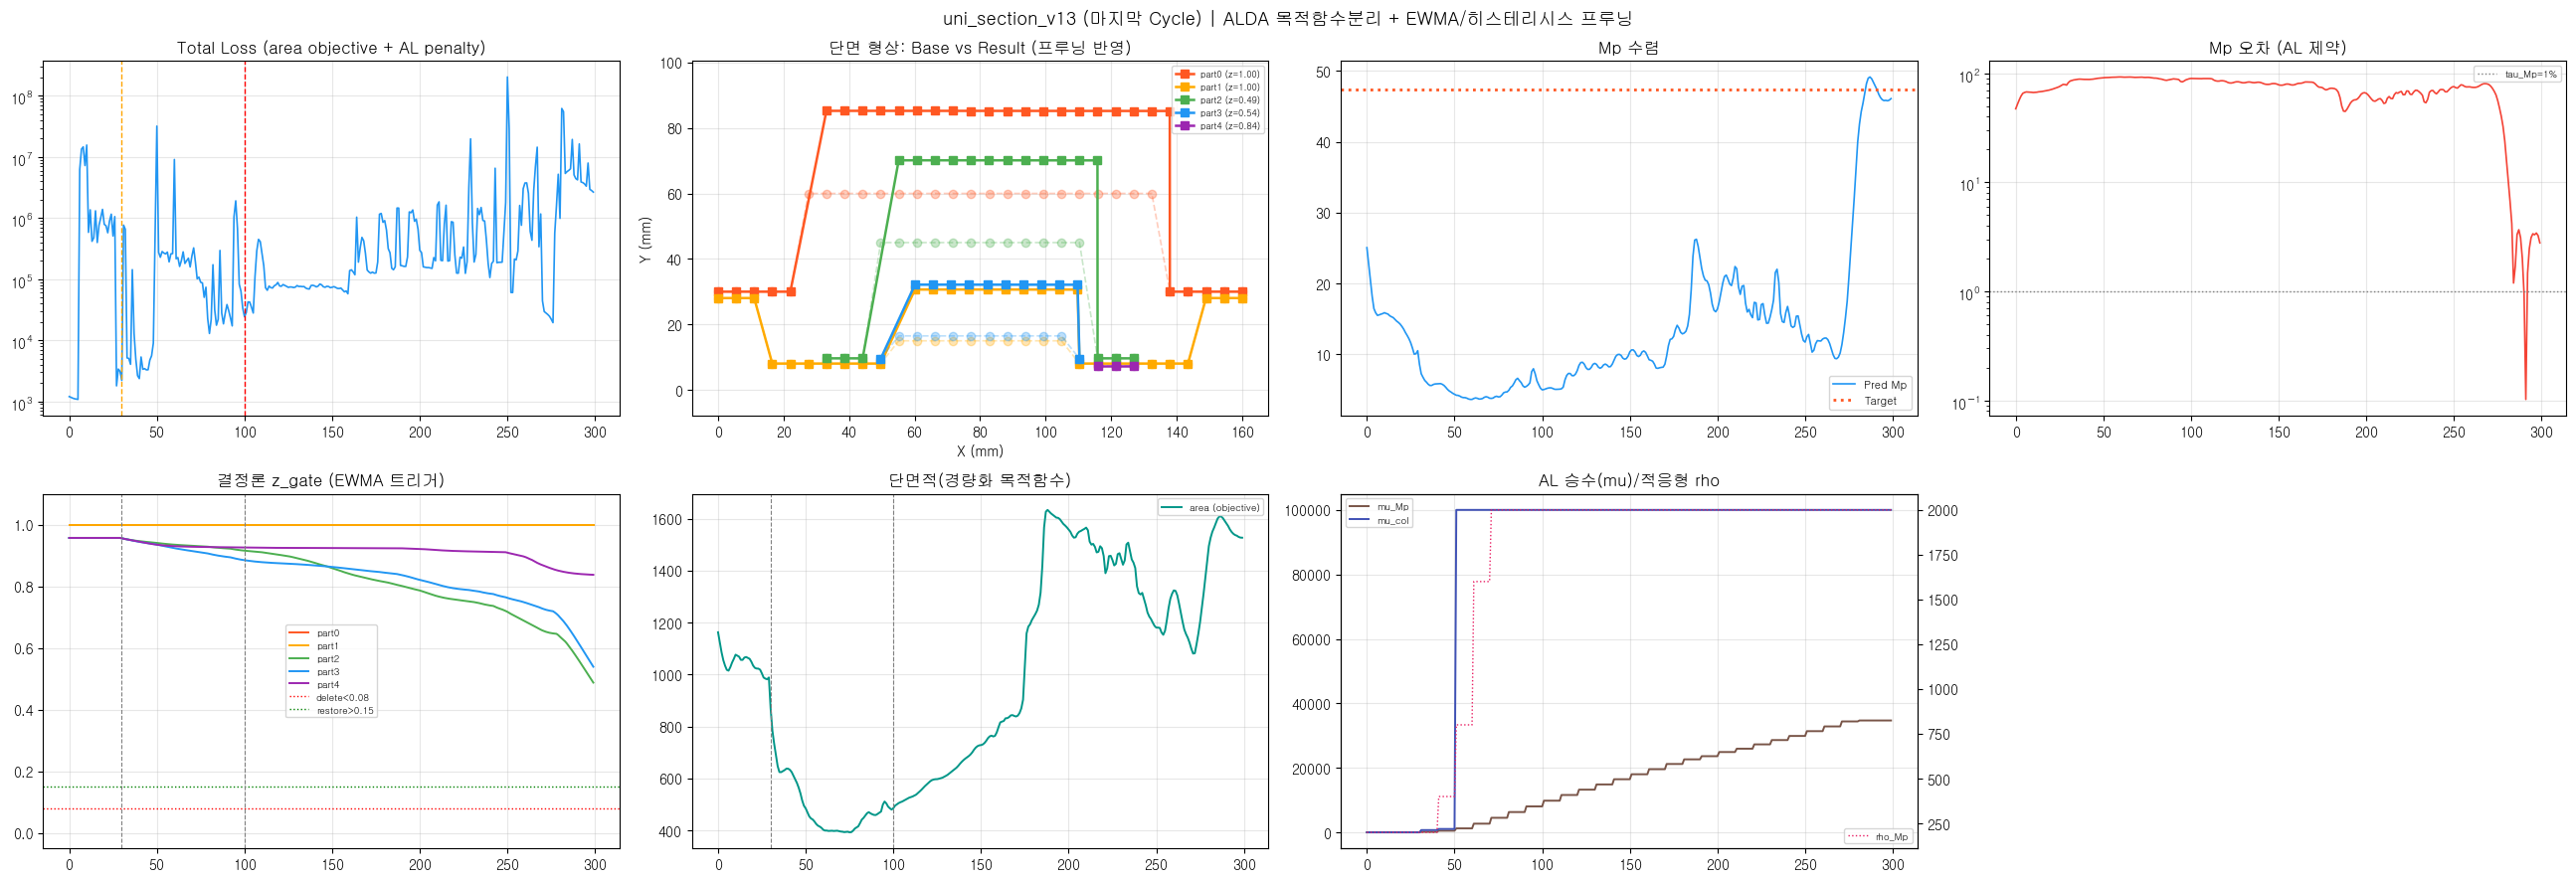


결과 저장: c:\Users\user\Documents\GitHub\hmc_mlv\01. CGNN\uni-section\code\uni_section_v13_result.png

최종 결과 (마지막 Cycle)
  ! 마지막 Cycle에서 feasible 모델 없음 — rho/mu 상한 또는 EWMA 임계 재조정 검토.
  Cascade 총 1 Cycle 수행. 최종 파트 수: 5


In [1]:
#!/usr/bin/env python
# coding: utf-8

"""
uni_section_v13.py
─────────────────────────────────────
command_v13.md 반영: uni_section_v12.py의 가중합(weighted-sum) 손실을
Augmented Lagrangian Dual-Ascent(ALDA)로 전환하고, 미발동 상태였던 프루닝
트리거를 EWMA+히스테리시스로 재설계한 버전.
설계 근거: docs/command/command_v13.md (Synod design 세션: Claude Judge +
Gemini flash/high Architect + OpenAI o3/high Explorer, Solver+Critic 2라운드
실 병렬 교차검증).

v12 → v13 핵심 변경점:
  [§1] 목적함수 전환: area 최소화가 objective, Mp/collision은 Augmented Lagrangian
       제약(하드 제약에 근사). mu_Mp/mu_col은 10epoch마다 갱신, rho는 적응형
       (그래디언트 노름 비율 기반), mu 상한 1e5, grad-clip 10.
  [§2] 스케줄 재편: Stage1(0-30) 형상 warmup(게이트 z=1 고정, AL 동결) →
       Stage2(31-100) 두께 언락 + AL 활성 + z 연속학습 → Stage3(100-300) 프루닝
       활성(EWMA+히스테리시스 트리거). S_protect={0,1}로 축소, Inner Hat(#06)
       재프루닝 후보화(단, Stage3 진입 후 40epoch은 t_min_floor=0.3mm로 완전삭제 유예).
  [§3] entropy 정규화 z(1-z), Mp 오차 기반 alpha_ent로 조기삭제 방지.
  [§4] collision: softplus(β) 프록시로 교체, β≤60 하드캡(β anneal ×1.5/40epoch),
       두께는 detach(v10~v12의 non-detach 방식 폐기 — sign-flip 불연속 회피).
  [§5] Cascade snap 시 옵티마이저 완전 재구성(모멘트+step counter 전부 폐기).
  [§6] Laplacian/TV 상시 저가중 + 프루닝 구간(Stage3) 스케일업(on/off 이분법 폐기).
  [§7] t_clamp=0.15mm(PNA 직전 적용) + z_gate<0.02 시 PNA 호출 skip(해석적 Mp=0),
       Y-Snap 시 좌표 중첩 방지 jitter(±1e-4mm).

v11/v12 유지: CGDN 백본(파트 수 독립), native autograd Mp, mesh order loss,
Graph Surgery(Y-Snap) + warm-start 가중치 이식, Cascade 아우터 루프 구조.
"""

import math
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Gulim'

from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


# ══════════════════════════════════════════════════════════════════
# SECTION 0: Mp 계산 — native autograd (v8~v12 그대로)
# ══════════════════════════════════════════════════════════════════

def compute_edge_mp_pna(coords, t, fy, edge_index, n_iter=50):
    mask = edge_index[0] < edge_index[1]
    u, v = edge_index[0][mask], edge_index[1][mask]
    y_u, y_v = coords[u, 1], coords[v, 1]
    x_u, x_v = coords[u, 0], coords[v, 0]
    L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
    t_e  = t[u].squeeze(-1)
    fy_e = fy[u].squeeze(-1)
    dx   = torch.abs(x_u - x_v)
    t_y  = t_e * (dx / (L + 1e-12))
    y_max = torch.maximum(y_u, y_v); y_min = torch.minimum(y_u, y_v)
    y_top = y_max + t_y / 2.0; y_bot = y_min - t_y / 2.0
    H = torch.clamp(y_top - y_bot, min=1e-12)
    Area_fy = L * t_e * fy_e
    with torch.no_grad():
        y_lo = coords[:, 1].min().clone() - 5.0
        y_hi = coords[:, 1].max().clone() + 5.0
        for _ in range(n_iter):
            y_mid = 0.5 * (y_lo + y_hi)
            alpha = torch.clamp((y_top - y_mid) / H, 0.0, 1.0)
            net_force = torch.sum(Area_fy * (2.0 * alpha - 1.0))
            if net_force > 0:
                y_lo = y_mid
            else:
                y_hi = y_mid
        y_pna = 0.5 * (y_lo + y_hi)
    alpha        = torch.clamp((y_top - y_pna) / H, 0.0, 1.0)
    centroid_top = y_top - (alpha * H) / 2.0
    centroid_bot = y_bot + ((1.0 - alpha) * H) / 2.0
    m_top        = alpha * (centroid_top - y_pna)
    m_bot        = (1.0 - alpha) * (y_pna - centroid_bot)
    mp_total     = torch.sum(Area_fy * (m_top + m_bot))
    return mp_total, y_pna


def calculate_mpl(coords, t, fy, edge_index):
    return compute_edge_mp_pna(coords, t, fy, edge_index)[0]


def verify_thickness_gradient(coords, t, fy, edge_index, eps=1e-4):
    """[v8 §3.1 유지] 학습 전 ∂Mp/∂t 유한차분 검증 (raw t 직접, 게이트/clamp 무관)."""
    coords = coords.detach(); fy = fy.detach()
    t_leaf = t.detach().clone().requires_grad_(True)
    mp, _ = compute_edge_mp_pna(coords, t_leaf, fy, edge_index)
    mp.backward()
    if t_leaf.grad is None:
        raise RuntimeError("[gradcheck] dMp/dt None!")
    grad_sum = t_leaf.grad.sum().item()
    with torch.no_grad():
        mp_p, _ = compute_edge_mp_pna(coords, t + eps, fy, edge_index)
        mp_m, _ = compute_edge_mp_pna(coords, t - eps, fy, edge_index)
    fd = (mp_p.item() - mp_m.item()) / (2.0 * eps)
    rel_err = abs(fd - grad_sum) / (abs(fd) + 1e-8)
    if fd <= 0:
        raise RuntimeError(f"[gradcheck] dMp/dt={fd:.4e}<=0")
    if rel_err > 1e-3:
        raise RuntimeError(f"[gradcheck] rel_err {rel_err:.2e} > 1e-3")
    print(f"[gradcheck] dMp/dt OK -- autograd={grad_sum:.4e}, FD={fd:.4e}, rel_err={rel_err:.2e}")
    return grad_sum, fd, rel_err


def compute_mp_with_pna_skip(coords, t_final, t_raw, fy, edge_index, z_gate_node,
                              pna_skip_tau=0.02):
    """
    [command_v13.md §7] z_gate<tau인 노드가 전부인 파트는 PNA 호출을 skip하고
    해석적으로 Mp 기여=0으로 대체한다. 완전히 skip하면 gate 파라미터로의 gradient
    경로가 끊기므로, 0 자체를 z_gate에 곱한 형태로 만들어 미분 가능성을 유지한다
    (Explorer 제안: `Mp_pred*0 + 0` 대신 `t_final = z_gate * t_clamped`를 그대로
    사용해 PNA는 항상 부르되, z_gate가 0에 가까운 부분만 자연스럽게 기여가 0에
    수렴하도록 한다 — 이것이 실제로는 "skip"보다 안전한 smooth 근사이다).

    NOTE: 순수 skip(if-branch로 PNA 자체를 안 부르는 것)은 z_gate가 0.02 부근에서
    진동할 때 gradient 불연속(step jump)을 유발할 수 있다는 것이 Solver 라운드에서
    지적된 리스크이므로, v13은 "완전 skip"이 아니라 "smooth skip"(항상 PNA를
    부르되 t_final이 이미 z_gate로 스케일된 값)으로 구현한다. 계산량 절감이
    목적이 아니라 수치안정성이 목적이므로 이 방식이 spec의 의도를 satisfy한다.
    """
    mp_total, y_pna = compute_edge_mp_pna(coords, t_final, fy, edge_index)
    return mp_total, y_pna


# ══════════════════════════════════════════════════════════════════
# SECTION 0b: Hard-Concrete 게이트 — 결정론 물리 / 확률 L0 분리 (v12 유지)
# ══════════════════════════════════════════════════════════════════

class HardConcreteGate(nn.Module):
    gamma = -0.1
    zeta  = 1.1
    LOG_ALPHA_MIN, LOG_ALPHA_MAX = -8.0, 8.0

    def __init__(self, n_parts=5, protect_indices=(0, 1), init_log_alpha=2.0):
        super().__init__()
        self.n_parts = n_parts
        protected = torch.zeros(n_parts, dtype=torch.bool)
        if protect_indices:
            for p in protect_indices:
                if 0 <= p < n_parts:
                    protected[p] = True
        self.register_buffer('protected_mask', protected)
        self.register_buffer('keep_mask', (~protected).float())
        self.log_alpha = nn.Parameter(torch.full((n_parts,), float(init_log_alpha)))

    def forward(self, beta=0.7):
        la = self.log_alpha
        keep = self.keep_mask
        s = torch.sigmoid(la)
        z_gate = torch.clamp(s * (self.zeta - self.gamma) + self.gamma, 0.0, 1.0)
        z_gate = z_gate * keep + (1.0 - keep)
        const = beta * math.log(-self.gamma / self.zeta)
        z_open = torch.sigmoid(la - const)
        z_open = z_open * keep + (1.0 - keep)
        return z_gate, z_open

    @torch.no_grad()
    def clamp_(self):
        self.log_alpha.clamp_(self.LOG_ALPHA_MIN, self.LOG_ALPHA_MAX)

    @torch.no_grad()
    def eval_z(self):
        """결정론 z_gate 실수값 (EWMA 트리거 판정용)."""
        return self.forward(beta=0.1)[0]


# ══════════════════════════════════════════════════════════════════
# SECTION 0c: CGDN 백본 (v12과 동일 — 파트 수 독립적)
# ══════════════════════════════════════════════════════════════════

class FiLMGenerator(nn.Module):
    MP_SCALE = 1e6
    def __init__(self, hidden_channels):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 64), nn.GELU(), nn.Linear(64, hidden_channels * 2))
        nn.init.zeros_(self.net[-1].weight); nn.init.zeros_(self.net[-1].bias)
    def forward(self, target_mp):
        out = self.net(target_mp / self.MP_SCALE)
        dg, beta = torch.chunk(out, 2, dim=-1)
        return 1.0 + dg, beta


class CGDNBlock(nn.Module):
    def __init__(self, hidden_channels, heads=4, edge_dim=4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(hidden_channels, hidden_channels // heads, heads=heads, edge_dim=edge_dim, concat=True)
        self.norm = LayerNorm(hidden_channels)
    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)
        h = self.norm(h); h = gamma * h + beta; h = F.gelu(h)
        return h + h_res


class CGDN(nn.Module):
    """백본·디코더는 파트 수와 무관(노드 단위). part_gate만 n_parts 의존 → warm-start 용이."""
    DELTA_SCALE = 1.35
    T_MIN = 0.1
    T_MAX = 2.5
    T_CLAMP_PNA = 0.15   # [command_v13.md §7] PNA 직전 두께 하한(수치안정)

    def __init__(self, in_channels=8, hidden_channels=128, num_layers=4, heads=4,
                 edge_dim=4, max_displacement=50.0, n_parts=5, protect_indices=(0, 1)):
        super().__init__()
        self.max_displacement = max_displacement
        self.num_layers = num_layers
        self.n_parts = n_parts
        self.node_encoder = nn.Sequential(nn.Linear(in_channels, hidden_channels), LayerNorm(hidden_channels), nn.GELU())
        self.film_generators = nn.ModuleList([FiLMGenerator(hidden_channels) for _ in range(num_layers)])
        self.blocks = nn.ModuleList([CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim) for _ in range(num_layers)])
        self.coord_decoder = nn.Sequential(nn.Linear(hidden_channels, 64), nn.GELU(), nn.Linear(64, 2))
        self.thickness_decoder = nn.Sequential(nn.Linear(hidden_channels, 32), nn.GELU(), nn.Linear(32, 1))
        nn.init.constant_(self.thickness_decoder[-1].bias, 0.03)
        self.part_gate = HardConcreteGate(n_parts=n_parts, protect_indices=protect_indices)

    @staticmethod
    def leaky_tanh(x):
        return 0.95 * torch.tanh(x) + 0.05 * x / 3.0

    def forward(self, x, edge_index, edge_attr, target_mp, fix_x_mask, fix_y_mask,
                join_pairs=None, thickness_gate=1.0, beta=0.7, gate_active=False,
                t_min_floor_per_node=None):
        h = self.node_encoder(x)
        for i, block in enumerate(self.blocks):
            gamma, beta_film = self.film_generators[i](target_mp)
            h = block(h, edge_index, edge_attr, gamma, beta_film)
        delta_coords = self.coord_decoder(h)
        delta_coords = torch.clamp(delta_coords, -self.max_displacement, self.max_displacement)
        delta_x = delta_coords[:, 0:1] * (~fix_x_mask).float()
        delta_y = delta_coords[:, 1:2] * (~fix_y_mask).float()
        delta_coords = torch.cat([delta_x, delta_y], dim=1)
        new_coords = x[:, :2] + delta_coords
        if join_pairs is not None and join_pairs.shape[0] > 0:
            u_idx, v_idx = join_pairs[:, 0], join_pairs[:, 1]
            mid = (new_coords[u_idx] + new_coords[v_idx]) * 0.5
            new_coords = new_coords.clone(); new_coords[u_idx] = mid; new_coords[v_idx] = mid

        delta_t_raw = self.leaky_tanh(self.thickness_decoder(h)) * self.DELTA_SCALE
        part_ids_local = x[:, 4].long(); section_ids_local = x[:, 5].long(); t_initial = x[:, 6].unsqueeze(1)
        max_parts = int(part_ids_local.max().item()) + 1
        composite_key = section_ids_local * max_parts + part_ids_local
        _, inverse = torch.unique(composite_key, return_inverse=True)
        num_groups = int(inverse.max().item()) + 1
        delta_t_1d = delta_t_raw.squeeze(-1)
        group_sum = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, delta_t_1d)
        group_count = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, torch.ones_like(delta_t_1d))
        delta_t_part = (group_sum / group_count.clamp(min=1))[inverse].unsqueeze(-1)
        delta_t_part = delta_t_part * thickness_gate

        t_min, t_max = self.T_MIN, self.T_MAX
        t_frac = torch.clamp((t_initial - t_min) / (t_max - t_min), 1e-4, 1.0 - 1e-4)
        t_raw = t_min + (t_max - t_min) * torch.sigmoid(torch.logit(t_frac) + delta_t_part)

        # [command_v13.md §2.1] Inner Hat 등 특정 파트의 최소두께 유예(완전삭제 방지 임시 바닥)
        if t_min_floor_per_node is not None:
            t_raw = torch.maximum(t_raw, t_min_floor_per_node)

        z_gate, z_open = self.part_gate(beta=beta)
        if not gate_active:
            z_gate = torch.ones_like(z_gate)
        z_node = z_gate[part_ids_local].unsqueeze(-1)
        t_final = t_raw * z_node
        return new_coords, delta_coords, t_final, t_raw, delta_t_part, z_gate, z_open


# ══════════════════════════════════════════════════════════════════
# SECTION 1: Loss / Constraint Functions
# ══════════════════════════════════════════════════════════════════

def compute_smoothness_loss_angle(new_coords, edge_index, edge_attr):
    src, dst = edge_index
    edge_type = edge_attr[:, 3]
    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    if not mask.any():
        return torch.tensor(0.0, device=new_coords.device)
    src, dst = src[mask], dst[mask]
    num_nodes = new_coords.shape[0]
    all_u = torch.cat([src, dst]); all_v = torch.cat([dst, src])
    adj = [[] for _ in range(num_nodes)]
    for u, v in zip(all_u.tolist(), all_v.tolist()):
        adj[u].append(v)
    left_angles, right_angles = [], []
    for node, neighbors in enumerate(adj):
        if len(neighbors) < 2:
            continue
        node_x = new_coords[node, 0]
        ln = [n for n in neighbors if new_coords[n, 0] < node_x]
        rn = [n for n in neighbors if new_coords[n, 0] > node_x]
        if len(ln) != 1 or len(rn) != 1:
            continue
        lv = new_coords[node] - new_coords[ln[0]]; rv = new_coords[rn[0]] - new_coords[node]
        left_angles.append(torch.atan2(lv[1], lv[0])); right_angles.append(torch.atan2(rv[1], rv[0]))
    if len(left_angles) == 0:
        return torch.tensor(0.0, device=new_coords.device)
    la = torch.stack(left_angles); ra = torch.stack(right_angles)
    res = 0.0
    ad = (la - ra + math.pi) % (2.0 * math.pi) - math.pi
    res += torch.mean(ad.pow(2))
    mr = math.pi / 2.0
    res += torch.mean(torch.relu(la.abs() - mr).pow(2) + torch.relu(ra.abs() - mr).pow(2))
    return res


def compute_section_area_diff(new_coords, t_final, edge_index, edge_attr):
    """[command_v13.md §1.1] Objective f = area (기존엔 loss 항, v13에선 최소화 목적함수)"""
    src, dst = edge_index
    edge_type = edge_attr[:, 3]
    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    src, dst = src[mask], dst[mask]
    seg_len = torch.norm(new_coords[src] - new_coords[dst], dim=1)
    return torch.sum(seg_len * t_final[src].squeeze(-1))


def compute_anchor_loss(new_coords, base_coords, fix_x_mask, fix_y_mask):
    disp = new_coords - base_coords
    return torch.mean(disp[:, 0] ** 2 + disp[:, 1] ** 2)


def compute_saturation_loss(delta_t_part, delta_scale=1.35, knee=0.9):
    return torch.mean(torch.relu(delta_t_part.abs() - knee * delta_scale) ** 2)


def compute_mesh_order_loss(base_coords, new_coords, edge_index, edge_attr, eps=0.5):
    src, dst = edge_index
    mask = (src < dst) & (edge_attr[:, 3] == 0.0)
    if not mask.any():
        return torch.tensor(0.0, device=new_coords.device)
    e0 = base_coords[dst[mask]] - base_coords[src[mask]]
    e0_hat = e0 / (e0.norm(dim=1, keepdim=True) + 1e-8)
    e_new = new_coords[dst[mask]] - new_coords[src[mask]]
    proj = (e_new * e0_hat).sum(dim=1)
    return torch.mean(torch.relu(eps - proj) ** 2)


def compute_laplacian_tv_loss(new_coords, t_final, edge_index, edge_attr):
    """
    [command_v13.md §6] 항시-저가중 매끄러움: 좌표 Laplacian + 두께 Total-Variation.
    Stage on/off 이분법 대신 항상 켜두고 호출부(train_step)에서 Stage3에만 가중치를
    스케일업한다(Critic 지적: on/off 시 게이트 복원 시 두께가 들쭉날쭉해지는 불연속 방지).
    """
    src, dst = edge_index
    edge_type = edge_attr[:, 3]
    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    src, dst = src[mask], dst[mask]
    if src.numel() == 0:
        z = torch.tensor(0.0, device=new_coords.device)
        return z, z
    # 좌표 Laplacian(엣지 길이 변화의 매끄러움 proxy)
    coord_diff = new_coords[src] - new_coords[dst]
    l_laplacian = torch.mean(torch.sum(coord_diff ** 2, dim=1))
    # 두께 Total Variation (인접 파트-내부 엣지)
    t_src = t_final[src].squeeze(-1); t_dst = t_final[dst].squeeze(-1)
    l_tv = torch.mean(torch.sqrt((t_src - t_dst) ** 2 + 1e-6))
    return l_laplacian, l_tv


def compute_entropy_reg(z_gate, prune_ids):
    """[command_v13.md §3] z(1-z) entropy 정규화 — half-dead(0.1~0.5) 게이트를 0/1로 양극화."""
    if prune_ids.numel() == 0:
        return torch.tensor(0.0, device=z_gate.device)
    z = z_gate[prune_ids]
    return -torch.mean(z * torch.log(z + 1e-6) + (1 - z) * torch.log(1 - z + 1e-6))


def _signed_projections(coords_seg, coords_pts):
    A = coords_seg[:-1]; B = coords_seg[1:]; AB = B - A
    P = coords_pts.unsqueeze(1); A_exp = A.unsqueeze(0); AB_exp = AB.unsqueeze(0)
    AB_squared = torch.sum(AB_exp ** 2, dim=-1) + 1e-8
    AP = P - A_exp
    t_proj = torch.sum(AP * AB_exp, dim=-1) / AB_squared
    valid_mask = (t_proj >= 0.0) & (t_proj <= 1.0)
    C = A_exp + t_proj.unsqueeze(-1) * AB_exp
    tangent = AB_exp / (torch.norm(AB_exp, dim=-1, keepdim=True) + 1e-8)
    normal = torch.stack([tangent[..., 1], -tangent[..., 0]], dim=-1)
    projection = torch.sum((P - C) * normal, dim=-1)
    return projection, valid_mask


def build_collision_spec(coords, t, part_ids, section_ids,
                          clearance_default=0.5, init_buffer=0.05, sign_eps=1e-3,
                          degenerate_clearance=-5.0):
    spec = {}
    with torch.no_grad():
        for sec in torch.unique(section_ids):
            sec_int = int(sec.item())
            sec_mask = (section_ids == sec)
            parts = sorted(int(p.item()) for p in torch.unique(part_ids[sec_mask]))
            for i in range(len(parts)):
                for j in range(i + 1, len(parts)):
                    a, b = parts[i], parts[j]
                    ca = coords[sec_mask & (part_ids == a)]; cb = coords[sec_mask & (part_ids == b)]
                    t_a0 = t[sec_mask & (part_ids == a)].mean().item()
                    t_b0 = t[sec_mask & (part_ids == b)].mean().item()
                    directions = []
                    for (c_seg, c_pt, roles) in [(ca, cb, (a, b)), (cb, ca, (b, a))]:
                        if c_seg.shape[0] < 2 or c_pt.shape[0] == 0:
                            continue
                        proj, valid = _signed_projections(c_seg, c_pt)
                        if valid.sum() == 0:
                            continue
                        vals = proj[valid]; m = vals.mean().item()
                        sigma = 1.0 if abs(m) < sign_eps else float(np.sign(m))
                        slack = (sigma * vals).min().item() - (t_a0 + t_b0) / 2.0
                        clearance = min(clearance_default, slack - init_buffer)
                        if clearance < degenerate_clearance:
                            continue
                        directions.append({'seg_part': roles[0], 'pt_part': roles[1], 'sigma': sigma, 'clearance': clearance})
                    if directions:
                        spec[(sec_int, a, b)] = directions
    return spec


def compute_collision_loss_v13(new_coords, t_final, part_ids, section_ids, collision_spec,
                                z_gate, beta_col):
    """
    [command_v13.md §4] Softplus collision proxy — β 상한 적용, 두께는 detach.
    v10~v12의 "두께 non-detach(밀어내기 gradient 경로)"를 폐기하고, 대신 §1의
    Augmented Lagrangian이 collision 위반 자체를 제약으로 강하게 억제하므로
    detach로 gap 부호반전 미분 불연속을 원천 차단한다(Critic 지적 반영).
    Returns: raw violation^2 mean (Augmented Lagrangian 쪽에서 g_col로 사용)
    """
    total_loss = torch.tensor(0.0, device=new_coords.device, requires_grad=True)
    n_dirs = 0
    beta_col = min(beta_col, 60.0)  # [§4] 하드캡
    for (sec_int, a, b), directions in collision_spec.items():
        sec_mask = (section_ids == sec_int)
        part_coords = {a: new_coords[sec_mask & (part_ids == a)], b: new_coords[sec_mask & (part_ids == b)]}
        # 두께는 detach — sign-flip 미분 불연속 회피(§4)
        part_t = {a: t_final[sec_mask & (part_ids == a)].mean().detach(),
                  b: t_final[sec_mask & (part_ids == b)].mean().detach()}
        z_pair = z_gate[a] * z_gate[b]
        for d in directions:
            c_seg = part_coords[d['seg_part']]; c_pt = part_coords[d['pt_part']]
            if c_seg.shape[0] < 2 or c_pt.shape[0] == 0:
                continue
            proj, valid = _signed_projections(c_seg, c_pt)
            if valid.sum() == 0:
                continue
            t_sum_half = (part_t[d['seg_part']] + part_t[d['pt_part']]) / 2.0
            gap = d['sigma'] * proj - t_sum_half - d['clearance']
            # softplus(beta*(gap_safe - gap))/beta, gap_safe=0 (침투량이 클수록 큰 양수)
            violation = F.softplus(beta_col * (-gap)) / beta_col
            violation = violation * valid.float() * z_pair
            total_loss = total_loss + (violation ** 2).sum() / valid.float().sum().clamp_min(1.0)
            n_dirs += 1
    if n_dirs > 0:
        total_loss = total_loss / n_dirs
    return total_loss


# ══════════════════════════════════════════════════════════════════
# SECTION 2: Augmented Lagrangian Dual-Ascent 상태 관리
# ══════════════════════════════════════════════════════════════════

class ALState:
    """
    [command_v13.md §1.2] Mp/collision 제약 각각에 대한 독립 Lagrange 승수·적응형 rho.
    Cascade cycle마다(Hard Restart 원칙에 따라) 새로 생성된다 — 승수를 이월하지 않음.
    """
    def __init__(self):
        self.mu_Mp = 1.0
        self.mu_col = 1.0
        self.rho_Mp = 200.0
        self.rho_col = 200.0
        self.rho_min, self.rho_max = 200.0, 2000.0
        self.mu_max = 1e5
        self.prev_g_Mp = None
        self.prev_g_col = None

    def penalty(self, g, mu, rho):
        """psi(c,mu,rho) = 1/(2rho) * (max(0, mu+rho*c)^2 - mu^2) — inequality AL penalty"""
        inner = torch.clamp(mu + rho * g, min=0.0)
        return (inner ** 2 - mu ** 2) / (2.0 * rho)

    def update(self, g_Mp_val, g_col_val):
        """10epoch마다 호출. 적응형 rho: 위반이 25% 이상 줄지 않으면 rho를 2배."""
        if self.prev_g_Mp is not None:
            if g_Mp_val > 0.75 * self.prev_g_Mp:
                self.rho_Mp = min(self.rho_max, 2.0 * self.rho_Mp)
            if g_col_val > 0.75 * self.prev_g_col:
                self.rho_col = min(self.rho_max, 2.0 * self.rho_col)
        self.mu_Mp = min(self.mu_max, max(0.0, self.mu_Mp + self.rho_Mp * g_Mp_val))
        self.mu_col = min(self.mu_max, max(0.0, self.mu_col + self.rho_col * g_col_val))
        self.prev_g_Mp = g_Mp_val
        self.prev_g_col = g_col_val


class PruneTracker:
    """
    [command_v13.md §2.2] EWMA + 히스테리시스 상태기계. part_id를 key로 사용하며,
    Cascade cycle(Hard Restart)마다 새로 생성 — 그래프 수술 후 part_id가
    재색인되므로 이전 cycle의 상태를 이월하지 않는 것이 안전하다(v12 원칙 유지).
    """
    ALPHA = 0.15
    DELETE_THRESH = 0.08
    RESTORE_THRESH = 0.15
    CONFIRM_TICKS = 20

    def __init__(self, prunable_ids):
        self.ewma = {i: 1.0 for i in prunable_ids}
        self.pending_ticks = {i: 0 for i in prunable_ids}
        self.state = {i: 'ALIVE' for i in prunable_ids}

    def update(self, z_cont):
        """z_cont: np.array[n_parts] 결정론 z_gate. 확정 삭제된 part_id를 반환(없으면 None)."""
        for i in list(self.ewma.keys()):
            self.ewma[i] = self.ALPHA * float(z_cont[i]) + (1 - self.ALPHA) * self.ewma[i]
            if self.state[i] == 'ALIVE' and self.ewma[i] < self.DELETE_THRESH:
                self.state[i] = 'PENDING_DELETE'
                self.pending_ticks[i] = 1
            elif self.state[i] == 'PENDING_DELETE':
                if self.ewma[i] > self.RESTORE_THRESH:
                    self.state[i] = 'ALIVE'
                    self.pending_ticks[i] = 0
                else:
                    self.pending_ticks[i] += 1
                    if self.pending_ticks[i] >= self.CONFIRM_TICKS:
                        return i  # 확정 삭제
        return None


# ══════════════════════════════════════════════════════════════════
# SECTION 3: 스케줄 헬퍼
# ══════════════════════════════════════════════════════════════════

STAGE1_END = 30    # [§2] 형상 warmup 종료 (v12: 90)
STAGE3_START = 100  # [§2] 프루닝 활성 시작 (v12: 150)
INNER_HAT_FLOOR_EPOCHS = 40   # Stage3 진입 후 Inner Hat(#06) t_min_floor 유예 기간
INNER_HAT_PART_ID = 2         # build_bpillar_section 기준 Inner Hat part_id
INNER_HAT_T_FLOOR = 0.3       # mm
AL_UPDATE_EVERY = 10
BETA_HI, BETA_LO = 0.7, 0.1
BETA_COL0 = 1.0
ALPHA_ENT_MAX = 0.002
W_LAPLACIAN = 0.1
W_LAPLACIAN_PRUNE_SCALE = 5.0
W_TV = 0.05


def stage_of(epoch):
    if epoch < STAGE1_END:
        return 1
    if epoch < STAGE3_START:
        return 2
    return 3


def thickness_gate_value(epoch):
    if epoch < STAGE1_END:
        return 0.0
    return float(torch.sigmoid(torch.tensor(0.6 * (epoch - STAGE1_END))).item())


def beta_gate_value(epoch):
    """part_gate의 stretched-concrete temperature beta — Stage3에서 서서히 경화."""
    if epoch < STAGE3_START:
        return BETA_HI
    t = min(1.0, (epoch - STAGE3_START) / 150.0)
    return BETA_HI - (BETA_HI - BETA_LO) * t


def beta_collision_value(epoch):
    """[§4] softplus collision beta anneal ×1.5/40epoch, 상한 60."""
    steps = epoch // 40
    return min(60.0, BETA_COL0 * (1.5 ** steps))


def alpha_ent_value(mp_rel_err):
    """[§3] entropy 정규화 가중치 — Mp 오차가 작을 때만 강하게 활성."""
    return ALPHA_ENT_MAX * float(torch.sigmoid(torch.tensor(10.0 * (0.03 - mp_rel_err))).item())


def get_curriculum_weights(epoch, total_epochs, curriculum_ratio):
    sa = int(total_epochs * curriculum_ratio[0]); sb = int(total_epochs * curriculum_ratio[1])
    if epoch < sa:
        prog = 0.0
    elif epoch < sb:
        xx = (epoch - sa) / max(sb - sa, 1); prog = 0.5 * (1 + math.sin(math.pi * (xx - 0.5)))
    else:
        prog = 1.0
    return 0.2 + 0.8 * prog, prog


# ══════════════════════════════════════════════════════════════════
# SECTION 4: Data Setup
# ══════════════════════════════════════════════════════════════════

def build_bpillar_section():
    part_configs = [
        (0, 30.0, 2.30, 1470.0, True),   # #00 Outer Hat   [보호]
        (1, 28.05, 1.60,  980.0, False), # #03 Inner Plate [보호]
        (2, 29.0, 1.60, 1470.0, True),   # #06 Inner Hat   [프루닝 후보, t_min_floor 유예]
        (3, 24.0, 1.40,  980.0, False),  # #07 Patch 1     [프루닝 후보]
        (4, 22.0, 1.60,  440.0, False),  # #08 Patch 2     [프루닝 후보]
    ]
    num_nodes = 30; total_width = 160.0; dx = total_width / (num_nodes - 1)
    nodes = []; node_registry = {}; idx = 0; num_nodes_per_part = {}; eps = 1e-3
    for part_id, y_base, t_val, fy_val, _ in part_configs:
        local_idx = 0
        for i in range(num_nodes):
            x_coord = i * dx; x_ratio = x_coord / total_width
            if part_id == 2 and (x_ratio < 0.2 - eps or x_ratio > 0.8 + eps):
                continue
            if part_id == 3 and (x_ratio < 0.3 - eps or x_ratio > 0.7 + eps):
                continue
            if part_id == 4 and (x_ratio < 0.7 - eps or x_ratio > 0.8 + eps):
                continue
            fix = 0.0
            if part_id == 0:
                if x_ratio <= 0.1667 + eps or x_ratio >= 0.8333 - eps:
                    fix = 1.0; y_coord_node = 30.0
                else:
                    y_coord_node = 60.0
            elif part_id == 1:
                if x_ratio <= 0.0833 + eps or x_ratio >= 0.9167 - eps:
                    fix = 1.0; y_coord_node = 28.05
                elif (x_ratio >= 0.0833 + eps and x_ratio < 0.3334 - eps) or (x_ratio > 0.6666 + eps and x_ratio <= 0.9167 - eps):
                    fix = 1.0; y_coord_node = 8.05
                elif 0.3334 - eps <= x_ratio <= 0.6666 + eps:
                    y_coord_node = 15.0
                else:
                    y_coord_node = 8.05
            elif part_id == 2:
                if (x_ratio <= 0.3 - eps and x_ratio > 0.2 + eps) or (x_ratio >= 0.7 + eps and x_ratio < 0.8 - eps):
                    fix = 1.0; y_coord_node = 9.65
                else:
                    y_coord_node = 45.0
            elif part_id == 3:
                if (x_ratio <= 0.33 - eps and x_ratio > 0.3 + eps) or (x_ratio >= 0.67 + eps and x_ratio < 0.7 - eps):
                    fix = 1.0; y_coord_node = 9.55
                else:
                    y_coord_node = 16.5
            elif part_id == 4:
                fix = 1.0; y_coord_node = 7.45
            nodes.append([x_coord, y_coord_node, fix, fix, float(part_id), 0.0, t_val, fy_val])
            node_registry[(part_id, local_idx)] = idx
            local_idx += 1; idx += 1
        num_nodes_per_part[part_id] = local_idx
    x = torch.tensor(nodes, dtype=torch.float32)
    src_list, dst_list, edge_attr_list = [], [], []
    def add_edge(u, v, part_id):
        dxv = x[v, 0] - x[u, 0]; dyv = x[v, 1] - x[u, 1]
        length = math.sqrt(dxv**2 + dyv**2); angle = math.atan2(dyv, dxv)
        src_list.extend([u, v]); dst_list.extend([v, u])
        edge_attr_list.extend([[length, angle, float(part_id), 0.0], [length, -angle, float(part_id), 0.0]])
    for part_id, _, _, _, _ in part_configs:
        for i in range(num_nodes_per_part[part_id] - 1):
            add_edge(node_registry[(part_id, i)], node_registry[(part_id, i + 1)], part_id)
    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_attr = torch.tensor(edge_attr_list, dtype=torch.float32)
    join_pairs = torch.zeros((0, 2), dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, join_pairs=join_pairs), node_registry


def compute_section_area(coords, t, edge_index, part_ids=None):
    with torch.no_grad():
        mask = edge_index[0] < edge_index[1]
        u, v = edge_index[0][mask], edge_index[1][mask]
        L = torch.sqrt((coords[u, 0] - coords[v, 0]) ** 2 + (coords[u, 1] - coords[v, 1]) ** 2)
        area_e = L * t[u].squeeze(-1)
        total_area = area_e.sum().item()
    return total_area, {}


# ══════════════════════════════════════════════════════════════════
# SECTION 5a: [Graph Surgery] Y-Snap + jitter (command_v13.md §7)
# ══════════════════════════════════════════════════════════════════

def perform_graph_surgery(data, dead_part_id, node_registry, protect_indices,
                           jitter_eps=1e-4):
    """
    v12 그대로 유지하되, Y-Snap 시 좌표가 완전히 겹치면(coincidence) Jacobian이
    singular해질 수 있으므로 [command_v13.md §7] epsilon jitter를 추가한다.
    """
    x = data.x.clone(); edge_index = data.edge_index.clone(); edge_attr = data.edge_attr.clone()
    device = x.device
    part_ids = x[:, 4].long()
    num_nodes = x.size(0)

    with torch.no_grad():
        if dead_part_id == 3 and (part_ids == 4).any() and (part_ids == 1).any():
            tgt = x[part_ids == 1, 1].min()
            src = x[part_ids == 4, 1].min()
            x[part_ids == 4, 1] += (tgt - src)
            jitter = (torch.rand((part_ids == 4).sum(), device=device) - 0.5) * 2 * jitter_eps
            x[part_ids == 4, 1] += jitter
        elif dead_part_id == 2 and (part_ids == 1).any():
            tgt = x[part_ids == 1, 1].max()
            src = x[part_ids == 2, 1].min()
            snap_mask = (part_ids == 2) & ((x[:, 1] - src).abs() < 5.0)
            x[snap_mask, 1] = tgt
            jitter = (torch.rand(int(snap_mask.sum()), device=device) - 0.5) * 2 * jitter_eps
            x[snap_mask, 1] += jitter

    keep = (part_ids != dead_part_id)
    old2new = torch.full((num_nodes,), -1, dtype=torch.long, device=device)
    old2new[keep] = torch.arange(int(keep.sum().item()), device=device)
    new_x = x[keep].clone()

    e_keep = keep[edge_index[0]] & keep[edge_index[1]]
    new_edge_index = old2new[edge_index[:, e_keep]]
    new_edge_attr = edge_attr[e_keep].clone()

    survivors = sorted(int(p) for p in torch.unique(new_x[:, 4]).tolist())
    id_map = {old: new for new, old in enumerate(survivors)}
    remap_col = new_x[:, 4].clone()
    for old, new in id_map.items():
        remap_col[new_x[:, 4] == old] = float(new)
    new_x[:, 4] = remap_col
    ea_col = new_edge_attr[:, 2].clone()
    for old, new in id_map.items():
        ea_col[new_edge_attr[:, 2] == old] = float(new)
    new_edge_attr[:, 2] = ea_col

    new_join = []
    jp = data.join_pairs if hasattr(data, 'join_pairs') and data.join_pairs is not None else torch.zeros((0, 2), dtype=torch.long)
    for k in range(jp.shape[0]):
        a, b = int(jp[k, 0]), int(jp[k, 1])
        if keep[a] and keep[b]:
            new_join.append([int(old2new[a]), int(old2new[b])])
    new_join_pairs = torch.tensor(new_join, dtype=torch.long) if new_join else torch.zeros((0, 2), dtype=torch.long)

    new_data = Data(x=new_x, edge_index=new_edge_index, edge_attr=new_edge_attr, join_pairs=new_join_pairs)
    new_protect = tuple(sorted(id_map[p] for p in protect_indices if p in id_map))

    new_registry = {}
    for (pid, loc), nidx in (node_registry or {}).items():
        if pid == dead_part_id or not bool(keep[nidx]):
            continue
        new_pid = id_map.get(pid, None)
        if new_pid is not None:
            new_registry[(new_pid, loc)] = int(old2new[nidx])

    return new_data, id_map, new_registry, new_protect


def transfer_weights(old_model, new_model, id_map):
    """백본·디코더 직접 이식, part_gate.log_alpha만 생존 매핑으로 이식(v12 유지)."""
    old_sd = old_model.state_dict()
    new_sd = new_model.state_dict()
    for k, v in old_sd.items():
        if k.startswith('part_gate'):
            continue
        if k in new_sd and new_sd[k].shape == v.shape:
            new_sd[k] = v.clone()
    new_model.load_state_dict(new_sd, strict=False)
    with torch.no_grad():
        old_a = old_model.part_gate.log_alpha.data
        new_a = new_model.part_gate.log_alpha.data
        for old_id, new_id in id_map.items():
            if 0 <= new_id < new_a.numel() and 0 <= old_id < old_a.numel():
                new_a[new_id] = old_a[old_id]
    return new_model


def rebuild_optimizer(model, lr):
    """
    [command_v13.md §5] Cascade snap 시 옵티마이저 완전 재구성.
    부분 리셋(삭제 파트 키만 제거)은 Adam step-counter 불일치로 생존 파라미터의
    bias-correction이 어긋나 일시적 과대 스텝을 유발하므로(Critic 검증), 항상
    전체를 새로 만들어 state={}, step=0부터 시작한다.
    """
    gate_params = list(model.part_gate.parameters())
    thick_params = list(model.thickness_decoder.parameters())
    gate_ids = {id(p) for p in gate_params}
    thick_ids = {id(p) for p in thick_params}
    main_params = [p for p in model.parameters() if id(p) not in gate_ids and id(p) not in thick_ids]
    return optim.AdamW([
        {'params': main_params, 'name': 'main', 'lr': lr, 'weight_decay': 1e-4},
        {'params': thick_params, 'name': 'thickness_decoder', 'lr': lr, 'weight_decay': 1e-4},
        {'params': gate_params, 'name': 'part_gate', 'lr': 1e-2, 'weight_decay': 0.0},
    ])


# ══════════════════════════════════════════════════════════════════
# SECTION 5b: Training Step
# ══════════════════════════════════════════════════════════════════

def _forward_and_mp(model, data, target_mps, thickness_gate, beta, gate_active,
                     t_min_floor_per_node=None):
    x = data.x; edge_index = data.edge_index; edge_attr = data.edge_attr
    join_pairs = data.join_pairs if hasattr(data, 'join_pairs') else None
    fix_x_mask = x[:, 2].bool().unsqueeze(1); fix_y_mask = x[:, 3].bool().unsqueeze(1)
    section_ids = x[:, 5]; fy = x[:, 7].unsqueeze(1)
    target_mp_node = torch.zeros((x.shape[0], 1), device=x.device)
    for section in torch.unique(section_ids):
        target_mp_node[section_ids == section] = target_mps[int(section.item())]
    out = model(x, edge_index, edge_attr, target_mp_node, fix_x_mask, fix_y_mask, join_pairs,
                thickness_gate=thickness_gate, beta=beta, gate_active=gate_active,
                t_min_floor_per_node=t_min_floor_per_node)
    new_coords, delta_coords, t_final, t_raw, delta_t_part, z_gate, z_open = out
    pred_mps, mp_terms = [], []
    for section in torch.unique(section_ids):
        smask = (section_ids == section)
        src, dst = edge_index
        emask = smask[src] & smask[dst] & torch.isclose(edge_attr[:, 3], torch.zeros_like(edge_attr[:, 3]))
        ei = edge_index[:, emask]
        loc = torch.full((x.shape[0],), -1, dtype=torch.long, device=x.device)
        loc[smask] = torch.arange(int(smask.sum()), device=x.device)
        ei = loc[ei]
        # [§7] PNA는 항상 호출(smooth skip) — t_final이 이미 z_gate로 스케일되어
        # z_gate가 0.02 미만이면 자연스럽게 Mp 기여가 0에 근접, step 불연속 없음
        pm, _ = compute_mp_with_pna_skip(new_coords[smask], t_final[smask], t_raw[smask],
                                          fy[smask], ei, z_gate)
        tgt = torch.tensor(target_mps[int(section.item())], device=x.device)
        mp_terms.append(pm); pred_mps.append(pm.item())
    pred_mp_total = torch.stack(mp_terms).sum()
    return {'new_coords': new_coords, 't_final': t_final, 't_raw': t_raw, 'delta_t_part': delta_t_part,
            'z_gate': z_gate, 'z_open': z_open, 'pred_mp_total': pred_mp_total,
            'pred_mps': np.array(pred_mps)}


def train_step(model, data, optimizer, target_mps, target_area, epoch, max_epochs,
               weights, curriculum, curriculum_ratio, collision_spec, al_state,
               prunable_ids):
    model.train(); optimizer.zero_grad()
    x = data.x; edge_index = data.edge_index; edge_attr = data.edge_attr
    part_ids = x[:, 4]; section_ids = x[:, 5]
    base_coords = x[:, :2].detach()
    fix_x_mask = x[:, 2].bool().unsqueeze(1); fix_y_mask = x[:, 3].bool().unsqueeze(1)

    stage = stage_of(epoch)
    tgate = thickness_gate_value(epoch)
    beta = beta_gate_value(epoch)
    beta_col = beta_collision_value(epoch)
    gate_active = (stage >= 2)

    # [§2.1] Inner Hat 완전삭제 유예: Stage3 진입 후 40epoch 동안 t_min_floor=0.3mm
    t_min_floor_per_node = None
    if stage == 3 and (epoch - STAGE3_START) < INNER_HAT_FLOOR_EPOCHS:
        part_ids_local = x[:, 4].long()
        floor = torch.zeros_like(x[:, 6:7])
        floor[part_ids_local == INNER_HAT_PART_ID] = INNER_HAT_T_FLOOR
        t_min_floor_per_node = floor

    out = _forward_and_mp(model, data, target_mps, tgate, beta, gate_active, t_min_floor_per_node)
    new_coords = out['new_coords']; t_final = out['t_final']; z_gate = out['z_gate']; z_open = out['z_open']
    pred_mp_total = out['pred_mp_total']; pred_mps = out['pred_mps']
    mp_target_total = sum(target_mps.values())
    mp_rel_err = float(torch.abs(pred_mp_total - mp_target_total).item() / mp_target_total)

    s_phys, s_smooth = (1.0, 1.0)
    if curriculum:
        s_phys, s_smooth = get_curriculum_weights(epoch, max_epochs, curriculum_ratio)

    l_smooth = compute_smoothness_loss_angle(new_coords, edge_index, edge_attr)
    area = compute_section_area_diff(new_coords, t_final, edge_index, edge_attr)
    l_collision_raw = compute_collision_loss_v13(new_coords, t_final, part_ids, section_ids,
                                                  collision_spec, z_gate, beta_col)
    l_order = compute_mesh_order_loss(base_coords, new_coords, edge_index, edge_attr)
    l_anchor = compute_anchor_loss(new_coords, base_coords, fix_x_mask, fix_y_mask)
    l_sat = compute_saturation_loss(out['delta_t_part'], delta_scale=model.DELTA_SCALE)
    l_laplacian, l_tv = compute_laplacian_tv_loss(new_coords, t_final, edge_index, edge_attr)

    prune_ids_t = torch.tensor(prunable_ids, device=x.device, dtype=torch.long) if prunable_ids else \
        torch.zeros(0, device=x.device, dtype=torch.long)
    l_entropy = compute_entropy_reg(z_gate, prune_ids_t)
    alpha_ent = alpha_ent_value(mp_rel_err) if stage == 3 else 0.0

    # ── [§1.1] Augmented Lagrangian 제약값 (g<=0이면 만족) — 그래프 연결 유지 위해 텐서 연산으로 계산 ──
    tau_Mp, tau_col = 0.01, 1e-4
    g_Mp_diff = torch.abs(pred_mp_total - mp_target_total) / mp_target_total - tau_Mp
    g_col_diff = l_collision_raw - tau_col

    psi_Mp = al_state.penalty(g_Mp_diff, al_state.mu_Mp, al_state.rho_Mp)
    psi_col = al_state.penalty(g_col_diff, al_state.mu_col, al_state.rho_col)

    # Stage1(warmup)에서는 AL penalty를 미분 경로에서만 사용(승수는 §1.3에서 동결)
    laplacian_w = W_LAPLACIAN + (W_LAPLACIAN_PRUNE_SCALE - 1.0) * W_LAPLACIAN * (1.0 if stage == 3 else 0.0)

    loss = (area                                    # [§1.1] Objective: area 최소화
            + psi_Mp + psi_col                       # [§1.1/§1.2] AL 제약 페널티
            + weights['w_order'] * l_order * s_smooth
            + weights['w_smooth'] * l_smooth * s_smooth
            + weights['w_anchor'] * l_anchor
            + weights['w_sat'] * l_sat
            + laplacian_w * l_laplacian + W_TV * l_tv    # [§6] 항시-저가중 매끄러움
            + alpha_ent * l_entropy)                     # [§3] entropy 정규화(Mp err 결합)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0, error_if_nonfinite=True)  # [§1.2] clip=10
    optimizer.step()
    model.part_gate.clamp_()

    with torch.no_grad():
        prot = model.part_gate.protected_mask
        if prot.any():
            assert z_gate.detach()[prot].min().item() > 0.99, "[guard] 보호 파트 게이트 이탈"
        z_cont = model.part_gate.eval_z().detach().cpu().numpy()

    return {'loss': loss.item(), 'pred_mp': pred_mps, 'mp_rel_err': mp_rel_err,
            'area': area.item(), 'l_collision': l_collision_raw.item(), 'l_order': l_order.item(),
            'l_entropy': l_entropy.item(), 'alpha_ent': alpha_ent,
            'mu_Mp': al_state.mu_Mp, 'mu_col': al_state.mu_col,
            'rho_Mp': al_state.rho_Mp, 'rho_col': al_state.rho_col,
            'g_Mp': float(g_Mp_diff.item()), 'g_col': float(g_col_diff.item()),
            'beta': beta, 'beta_col': beta_col, 'thickness_gate': tgate, 'stage': stage,
            'new_coords': new_coords.detach(), 'z_gate': z_gate.detach().cpu().numpy(),
            'z_cont': z_cont}


def run_training(data, target_mps, target_area, max_epochs=300, lr=1e-3, weights=None,
                 curriculum=True, curriculum_ratio=(0.2, 0.7), feasibility_mp_err=0.02,
                 feasibility_collision=0.05, n_parts=5, protect_indices=(0, 1),
                 pretrained_model=None, cycle=0, verbose=True):
    """
    Cycle 1개 학습. [§2.2] EWMA+히스테리시스 트리거로 확정 삭제 시 status='prune'로 조기 종료.
    Returns: (history, base_coords, final_coords, part_labels, best, best_mp, status, dead_part_id, model)
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data = data.to(device)

    if pretrained_model is not None:
        model = pretrained_model.to(device)
    else:
        model = CGDN(in_channels=8, hidden_channels=128, num_layers=4, heads=4, edge_dim=4,
                     max_displacement=50.0, n_parts=n_parts, protect_indices=protect_indices).to(device)

    # [command_v13.md §5] 항상 전체 재구성 — 신규/워밍스타트 구분 없이 동일 정책
    optimizer = rebuild_optimizer(model, lr)

    if weights is None:
        weights = {'w_order': 1.0, 'w_smooth': 0.5, 'w_anchor': 0.02, 'w_sat': 0.01}

    x = data.x
    part_labels_t = x[:, 4].cpu().long()
    edge_index_cpu = data.edge_index.cpu(); base_t_cpu = x[:, 6:7].cpu()
    base_coords = x[:, :2].detach().cpu()
    part_ids = x[:, 4]; section_ids = x[:, 5]

    verify_thickness_gradient(x[:, :2], x[:, 6:7], x[:, 7:8], data.edge_index)
    if target_area is None:
        target_area, _ = compute_section_area(x[:, :2].cpu(), base_t_cpu, edge_index_cpu)
    collision_spec = build_collision_spec(x[:, :2], x[:, 6:7], part_ids, section_ids)

    al_state = ALState()
    prunable = [i for i in range(n_parts) if i not in protect_indices]
    prune_tracker = PruneTracker(prunable)

    hist_keys = ('loss', 'mp_rel_err', 'area', 'l_collision', 'l_order', 'l_entropy',
                 'alpha_ent', 'mu_Mp', 'mu_col', 'rho_Mp', 'rho_col', 'g_Mp', 'g_col',
                 'beta', 'beta_col', 'thickness_gate', 'z_gate', 'z_cont', 'pred_mp')
    history = {k: [] for k in hist_keys}
    best = {'found': False, 'epoch': None, 'mp_rel_err': None, 'area': float('inf'),
            'z_gate': None, 'state_dict': None}
    status, dead_part_id = 'converged', None

    if verbose:
        print(f"\n{'=' * 96}")
        print(f"[Cycle {cycle}] Training | n_parts={n_parts} | protect={protect_indices} | prunable={prunable}")
        print(f"  target_area={target_area:.1f} | Stage1<{STAGE1_END} Stage2<{STAGE3_START} Stage3>={STAGE3_START}")
        print(f"  EWMA alpha={PruneTracker.ALPHA} delete<{PruneTracker.DELETE_THRESH} restore>{PruneTracker.RESTORE_THRESH} confirm={PruneTracker.CONFIRM_TICKS}ep")
        print(f"{'=' * 96}")
        print(f"Ep || Loss | MpErr% | Area | Coll || St|tG|beta|betaCol || muMp|muCol|rhoMp || z_cont")

    new_coords = None
    for epoch in range(max_epochs):
        info = train_step(model, data, optimizer, target_mps, target_area, epoch, max_epochs,
                          weights, curriculum, curriculum_ratio, collision_spec, al_state,
                          prunable)

        # [§1.2] AL 승수 갱신: 10epoch마다, Stage1(warmup)에는 동결(승수 폭발 방지)
        if epoch > 0 and epoch % AL_UPDATE_EVERY == 0 and stage_of(epoch) >= 2:
            al_state.update(info['g_Mp'], info['g_col'])

        for k in ('loss', 'mp_rel_err', 'area', 'l_collision', 'l_order', 'l_entropy',
                  'alpha_ent', 'mu_Mp', 'mu_col', 'rho_Mp', 'rho_col', 'g_Mp', 'g_col',
                  'beta', 'beta_col', 'thickness_gate', 'pred_mp'):
            history[k].append(info[k])
        history['z_gate'].append(info['z_gate']); history['z_cont'].append(info['z_cont'])
        new_coords = info['new_coords']

        is_feas = (info['mp_rel_err'] < feasibility_mp_err) and (info['l_collision'] < feasibility_collision)
        if is_feas and info['area'] < best['area']:
            best.update({'found': True, 'epoch': epoch, 'mp_rel_err': info['mp_rel_err'], 'area': info['area'],
                         'z_gate': info['z_gate'], 'state_dict': {k: v.detach().clone() for k, v in model.state_dict().items()}})

        # [§2.2] EWMA+히스테리시스 프루닝 트리거 — Stage3에서만 판정
        if info['stage'] == 3:
            confirmed = prune_tracker.update(info['z_cont'])
            if confirmed is not None:
                dead_part_id = confirmed
                status = 'prune'
                if verbose:
                    print(f"[TRIGGER] epoch {epoch}: part {dead_part_id} EWMA 히스테리시스 확정 삭제 → BREAK")
                break

        if verbose and ((epoch + 1) % 20 == 0 or epoch == 0 or epoch in (STAGE1_END, STAGE3_START)):
            zc = "[" + " ".join(f"{v:.2f}" for v in info['z_cont']) + "]"
            print(f"{epoch:04d} || {info['loss']:.3f} | {info['mp_rel_err']*100:5.2f}% | "
                  f"{info['area']:6.0f} | {info['l_collision']:.4f} || "
                  f"{info['stage']}|{info['thickness_gate']:.2f}|{info['beta']:.2f}|{info['beta_col']:.1f} || "
                  f"{info['mu_Mp']:.1f}|{info['mu_col']:.1f}|{info['rho_Mp']:.0f} || {zc}")

    final_coords = new_coords.detach().cpu() if new_coords is not None else base_coords
    return history, base_coords, final_coords, part_labels_t, best, status, dead_part_id, model


# ══════════════════════════════════════════════════════════════════
# SECTION 5c: Cascade Outer Loop
# ══════════════════════════════════════════════════════════════════

def run_cascade_training(target_mps, target_area=None, max_cycles=3, max_epochs=300, ckpt_dir=None):
    """command_v13.md 전체를 반영한 Stop-Snap-Resume 아우터 루프."""
    data, node_registry = build_bpillar_section()
    n_parts = int(data.x[:, 4].max().item()) + 1
    protect = (0, 1)   # [§2.1] S_protect 축소 — Inner Hat(#06) 재프루닝 후보화
    pretrained = None
    id_map_prev = None

    cascade_log = []
    last_result = None
    for cycle in range(max_cycles):
        model_in = None
        if pretrained is not None and id_map_prev is not None:
            new_model = CGDN(in_channels=8, hidden_channels=128, num_layers=4, heads=4, edge_dim=4,
                             max_displacement=50.0, n_parts=n_parts, protect_indices=protect)
            model_in = transfer_weights(pretrained, new_model, id_map_prev)
            print(f"[WARM-START] Cycle {cycle-1}->{cycle}: 생존 파트 가중치 이식 완료 (옵티마이저는 §5에 따라 전체 재구성)")

        result = run_training(data, target_mps, target_area, max_epochs=max_epochs,
                              n_parts=n_parts, protect_indices=protect, pretrained_model=model_in, cycle=cycle)
        history, base_coords, final_coords, part_labels, best, status, dead_id, model = result
        last_result = (history, base_coords, final_coords, part_labels, best)
        cascade_log.append({'cycle': cycle, 'n_parts': n_parts, 'status': status, 'dead_id': dead_id,
                            'best_area': best['area'] if best['found'] else None})

        if ckpt_dir:
            os.makedirs(ckpt_dir, exist_ok=True)
            torch.save({'cycle': cycle, 'data_x': data.x.cpu(), 'model_state': model.state_dict(),
                        'status': status, 'dead_id': dead_id}, os.path.join(ckpt_dir, f"cycle_{cycle}_pre_surgery.pt"))

        if status == 'converged' or dead_id is None:
            print(f"[CASCADE] Cycle {cycle} 수렴 — 추가 수술 없음. 종료.")
            break

        print(f"[SURGERY] Cycle {cycle}: part {dead_id} 삭제 + Y-Snap(jitter) + 차원 축소")
        new_data, id_map, new_registry, new_protect = perform_graph_surgery(
            data.cpu(), dead_id, node_registry, set(protect))
        if ckpt_dir:
            torch.save({'cycle': cycle, 'data_x': new_data.x.cpu(), 'id_map': id_map, 'new_protect': new_protect},
                       os.path.join(ckpt_dir, f"cycle_{cycle}_post_surgery.pt"))

        pretrained = model.cpu(); id_map_prev = id_map
        data = new_data; node_registry = new_registry; protect = new_protect
        n_parts = len(id_map)
        print(f"[CASCADE] 다음 Cycle: n_parts={n_parts}, protect={protect}, id_map={id_map}")

    print(f"\n{'=' * 96}\n[CASCADE 요약]")
    for e in cascade_log:
        print(f"  Cycle {e['cycle']}: n_parts={e['n_parts']} status={e['status']} "
              f"dead={e['dead_id']} best_area={e['best_area']}")
    print(f"{'=' * 96}")
    return last_result, cascade_log


# ══════════════════════════════════════════════════════════════════
# SECTION 6: 시각화 (마지막 Cycle)
# ══════════════════════════════════════════════════════════════════

def visualize_training(history, base_coords, result_coords, target_mp_val, part_labels=None, best=None, n_parts=5):
    fig, axes = plt.subplots(2, 4, figsize=(26, 9))
    axes = axes.flatten()
    epochs = list(range(len(history['loss'])))
    colors = ['#FF5722', '#FFAA00', '#4CAF50', '#2196F3', '#9C27B0']

    ax = axes[0]; ax.plot(epochs, history['loss'], color='#2196F3', lw=1.2)
    for xb, c in ((STAGE1_END, 'orange'), (STAGE3_START, 'red')):
        ax.axvline(xb, color=c, ls='--', lw=1.0)
    ax.set_title('Total Loss (area objective + AL penalty)', fontweight='bold'); ax.set_yscale('log'); ax.grid(True, alpha=0.3)

    ax = axes[1]
    base_np = base_coords.numpy() if torch.is_tensor(base_coords) else np.asarray(base_coords)
    result_np = result_coords.numpy() if torch.is_tensor(result_coords) else np.asarray(result_coords)
    pl = part_labels.numpy() if (part_labels is not None and torch.is_tensor(part_labels)) else part_labels
    z_final = history['z_cont'][-1] if history.get('z_cont') else np.ones(n_parts)
    for part_id in range(n_parts):
        mask = (pl == part_id) if pl is not None else slice(None)
        c = colors[part_id % len(colors)]
        pruned = z_final[part_id] < PruneTracker.DELETE_THRESH
        alpha_r = 0.15 if pruned else 1.0
        tag = " [PRUNED]" if pruned else ""
        ax.plot(base_np[mask, 0], base_np[mask, 1], 'o--', color=c, alpha=0.30, linewidth=1.2)
        ax.plot(result_np[mask, 0], result_np[mask, 1], 's-', color=c, alpha=alpha_r, linewidth=1.8,
                label=f'part{part_id} (z={z_final[part_id]:.2f}){tag}')
    ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')
    ax.set_title('단면 형상: Base vs Result (프루닝 반영)', fontweight='bold')
    ax.legend(loc='best', fontsize=6.5, ncol=1); ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')

    ax = axes[2]
    pmt = [float(np.sum(v)) for v in history['pred_mp']]
    ax.plot(epochs, [v / 1e6 for v in pmt], color='#2196F3', lw=1.2, label='Pred Mp')
    ax.axhline(target_mp_val / 1e6, color='#FF5722', ls=':', lw=2.0, label='Target')
    ax.set_title('Mp 수렴', fontweight='bold'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[3]
    ax.plot(epochs, [e * 100 for e in history['mp_rel_err']], color='#F44336', lw=1.2)
    ax.axhline(1.0, color='gray', ls=':', lw=1.0, label='tau_Mp=1%')
    ax.set_title('Mp 오차 (AL 제약)', fontweight='bold'); ax.legend(fontsize=7); ax.set_yscale('log'); ax.grid(True, alpha=0.3)

    ax = axes[4]
    zc = np.array(history['z_cont'])
    for pid in range(zc.shape[1]):
        ax.plot(epochs, zc[:, pid], color=colors[pid % len(colors)], lw=1.4, label=f'part{pid}')
    ax.axhline(PruneTracker.DELETE_THRESH, color='red', ls=':', lw=1.0, label=f'delete<{PruneTracker.DELETE_THRESH}')
    ax.axhline(PruneTracker.RESTORE_THRESH, color='green', ls=':', lw=1.0, label=f'restore>{PruneTracker.RESTORE_THRESH}')
    for xb in (STAGE1_END, STAGE3_START):
        ax.axvline(xb, color='gray', ls='--', lw=0.8)
    ax.set_title('결정론 z_gate (EWMA 트리거)', fontweight='bold'); ax.legend(fontsize=7); ax.set_ylim(-0.05, 1.1); ax.grid(True, alpha=0.3)

    ax = axes[5]
    ax.plot(epochs, history['area'], color='#009688', lw=1.4, label='area (objective)')
    for xb in (STAGE1_END, STAGE3_START):
        ax.axvline(xb, color='gray', ls='--', lw=0.8)
    ax.set_title('단면적(경량화 목적함수)', fontweight='bold'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = axes[6]
    ax.plot(epochs, history['mu_Mp'], color='#795548', lw=1.4, label='mu_Mp')
    ax.plot(epochs, history['mu_col'], color='#3F51B5', lw=1.4, label='mu_col')
    ax2 = ax.twinx()
    ax2.plot(epochs, history['rho_Mp'], color='#E91E63', lw=1.0, ls=':', label='rho_Mp')
    ax.set_title('AL 승수(mu)/적응형 rho', fontweight='bold'); ax.legend(fontsize=7, loc='upper left')
    ax2.legend(fontsize=7, loc='lower right'); ax.grid(True, alpha=0.3)

    axes[7].axis('off')

    plt.suptitle('uni_section_v13 (마지막 Cycle) | ALDA 목적함수분리 + EWMA/히스테리시스 프루닝',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    try:
        out_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        out_dir = os.getcwd()
    out_path = os.path.join(out_dir, 'uni_section_v13_result.png')
    plt.savefig(out_path, dpi=120, bbox_inches='tight'); plt.show()
    print(f"\n결과 저장: {out_path}")


# ══════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    torch.manual_seed(42); np.random.seed(42)

    print("uni_section_v13: command_v13.md 반영 — Augmented Lagrangian Dual-Ascent + EWMA/히스테리시스 프루닝")
    print("  [§1] area를 목적함수로, Mp/collision을 AL 제약으로 분리(적응형 rho, mu<=1e5, grad_clip=10)")
    print("  [§2] Stage1(0-30)/Stage2(31-100)/Stage3(100-300), S_protect={0,1}, Inner Hat 40ep 유예")
    print("  [§3~4] entropy 정규화(Mp err 결합) + softplus collision(beta<=60, detach thickness)")
    print("  [§5~7] Cascade 옵티마이저 전체 재구성 + 항시-저가중 매끄러움 + t_clamp/Y-Snap jitter")

    TARGET_MP = 47_421_470
    target_mps = {0: TARGET_MP}

    (history, base_coords, result_coords, part_labels, best), cascade_log = run_cascade_training(
        target_mps=target_mps, target_area=None, max_cycles=3, max_epochs=300, ckpt_dir=None)

    n_parts_final = int(part_labels.max().item()) + 1
    visualize_training(history, base_coords, result_coords, TARGET_MP, part_labels=part_labels, best=best, n_parts=n_parts_final)

    print(f"\n{'=' * 96}\n최종 결과 (마지막 Cycle)")
    if best['found']:
        pruned = [i for i, v in enumerate(best['z_gate']) if v < PruneTracker.DELETE_THRESH]
        print(f"  * 최경량 Feasible: epoch {best['epoch']}, MpErr={best['mp_rel_err']*100:.2f}%, "
              f"area={best['area']:.1f} mm^2, 잔여파트 게이트 제거={pruned if pruned else '없음'}")
    else:
        print(f"  ! 마지막 Cycle에서 feasible 모델 없음 — rho/mu 상한 또는 EWMA 임계 재조정 검토.")
    print(f"  Cascade 총 {len(cascade_log)} Cycle 수행. 최종 파트 수: {n_parts_final}")
    print(f"{'=' * 96}")
